In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_theme(style="whitegrid")

In [2]:
# Load central data
print("Loading Central Data...")
X_train_global = np.load("../data/processed/X_train.npy")
X_test_global = np.load("../data/processed/X_test.npy")
y_test_global = np.load("../data/processed/y_test.npy", allow_pickle=True)

print(f"Total Training Data: {len(X_train_global)} samples")

# Define FALCON Model
def build_falcon_model(input_dim=21):
    input_layer = layers.Input(shape=(input_dim,))
    encoded = layers.Dense(16, activation='relu')(input_layer)
    encoded = layers.Dense(8, activation='relu')(encoded)
    decoded = layers.Dense(16, activation='relu')(encoded)
    output_layer = layers.Dense(input_dim, activation='linear')(decoded)

    model = models.Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer='adam', loss='mse')
    return model

print("FALCON Architecture Ready.")

Loading Central Data...
Total Training Data: 1818477 samples
FALCON Architecture Ready.


In [3]:
# Create 3 Clients
print("Partitioning Data for 3 Clients...")
client_1_data, rest_data = train_test_split(X_train_global, test_size=0.66, random_state=42)
client_2_data, client_3_data = train_test_split(rest_data, test_size=0.5, random_state=42)

clients = [client_1_data, client_2_data, client_3_data]
client_names = ['A', 'B', 'C']

print("------Data Distribution------")
print(f"Client A: {client_1_data.shape} samples")
print(f"Client B: {client_2_data.shape} samples")
print(f"Client C: {client_3_data.shape} samples")

Partitioning Data for 3 Clients...
------Data Distribution------
Client A: (618282, 21) samples
Client B: (600097, 21) samples
Client C: (600098, 21) samples


In [9]:
# Federated Learning Simulation Setup
ROUNDS = 5     
EPOCHS_PER_ROUND = 1     

global_model = build_falcon_model()
global_weights = global_model.get_weights()

history_f1 = []

# Pre-convert labels to binary for fast loop evaluation ('BENIGN' = 0, Attack = 1)
y_true_numeric = np.array([0 if str(label).strip().upper() == 'BENIGN' else 1 for label in y_test_global])

print(f"Starting Federated Training for {ROUNDS} Rounds...\n")

for round_num in range(1, ROUNDS + 1):
    print(f"--- Round {round_num}/{ROUNDS} ---")
    local_weights_list = []

    # Phase 1: Local Training
    for i, client_data in enumerate(clients):
        local_model = build_falcon_model()
        local_model.set_weights(global_weights)
        local_model.fit(client_data, client_data, epochs=EPOCHS_PER_ROUND, batch_size=256, verbose=0)
        local_weights_list.append(local_model.get_weights())
        print(f" * Client {client_names[i]} finished training.")

    # Phase 2: Aggregation (FedAvg)
    print("Server Aggregating Weights...")
    new_global_weights = []
    for layer_weights_tuple in zip(*local_weights_list):
        averaged_layer = np.mean(np.array(layer_weights_tuple), axis=0)
        new_global_weights.append(averaged_layer)

    global_weights = new_global_weights
    global_model.set_weights(global_weights)

    # Phase 3: Round Monitoring Tracker (Using dynamic percentile to estimate progress)
    reconstructions = global_model.predict(X_test_global, batch_size=4096, verbose=0)
    mse = np.mean(np.power(X_test_global - reconstructions, 2), axis=1)
    
    round_threshold = np.percentile(mse, 95)
    y_pred = [1 if e > round_threshold else 0 for e in mse]
    
    f1 = f1_score(y_true_numeric, y_pred)
    history_f1.append(f1)
    print(f"Global Model F1 Score (Estimated): {f1:.4f}\n")

print("Federated Training Complete!")

Starting Federated Training for 5 Rounds...

--- Round 1/5 ---
 * Client A finished training.
 * Client B finished training.
 * Client C finished training.
Server Aggregating Weights...
Global Model F1 Score (Estimated): 0.1620

--- Round 2/5 ---
 * Client A finished training.
 * Client B finished training.
 * Client C finished training.
Server Aggregating Weights...
Global Model F1 Score (Estimated): 0.1635

--- Round 3/5 ---
 * Client A finished training.
 * Client B finished training.
 * Client C finished training.
Server Aggregating Weights...
Global Model F1 Score (Estimated): 0.1642

--- Round 4/5 ---
 * Client A finished training.
 * Client B finished training.
 * Client C finished training.
Server Aggregating Weights...
Global Model F1 Score (Estimated): 0.1659

--- Round 5/5 ---
 * Client A finished training.
 * Client B finished training.
 * Client C finished training.
Server Aggregating Weights...
Global Model F1 Score (Estimated): 0.1660

Federated Training Complete!


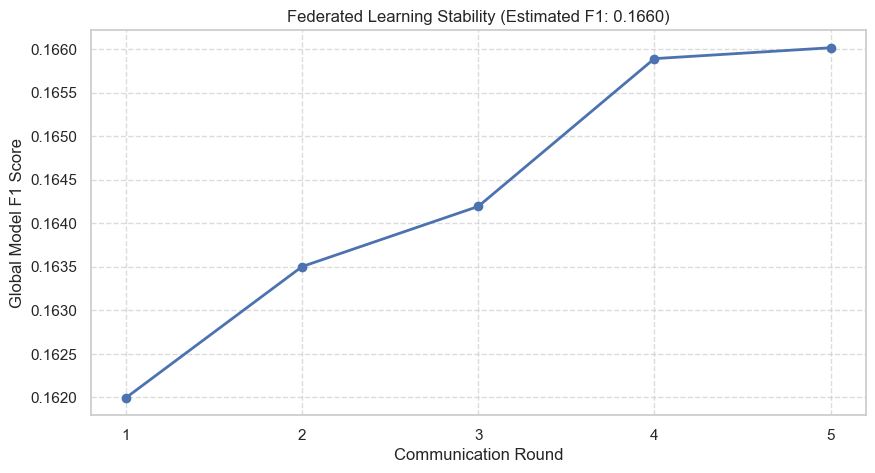

In [10]:
# Learning Curve Visualization
plt.figure(figsize=(10,5))
plt.plot(range(1, ROUNDS + 1), history_f1, marker='o', linestyle='-', color='b', linewidth=2)
plt.title(f"Federated Learning Stability (Estimated F1: {history_f1[-1]:.4f})")
plt.xlabel("Communication Round")
plt.ylabel("Global Model F1 Score")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(1, ROUNDS + 1))
plt.show()

In [11]:
print("Running Final Global Prediction & Optimization...")

# 1. Get Reconstructions
reconstructions = global_model.predict(X_test_global, batch_size=4096, verbose=1)
mse = np.mean(np.power(X_test_global - reconstructions, 2), axis=1)

# 2. Mathematically Find the Optimal Threshold via PR-Curve
print("\nCalculating Optimal Federated Threshold via PR-Curve...")
precisions, recalls, thresholds = precision_recall_curve(y_true_numeric, mse)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]

print(f"---> Found Optimal Federated Threshold: {optimal_threshold:.6f}")

# 3. Classify using the optimal threshold
y_pred_optimal = [1 if e > optimal_threshold else 0 for e in mse]

# 4. Final Metrics
accuracy = accuracy_score(y_true_numeric, y_pred_optimal)
f1 = f1_score(y_true_numeric, y_pred_optimal)
precision = precision_score(y_true_numeric, y_pred_optimal)
recall = recall_score(y_true_numeric, y_pred_optimal)

print(f"\n--- Federated Model Performance (Optimized) ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

Running Final Global Prediction & Optimization...
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 499us/step

Calculating Optimal Federated Threshold via PR-Curve...
---> Found Optimal Federated Threshold: 0.005662

--- Federated Model Performance (Optimized) ---
Accuracy:  0.7891
F1 Score:  0.8197
Precision: 0.7748
Recall:    0.8701


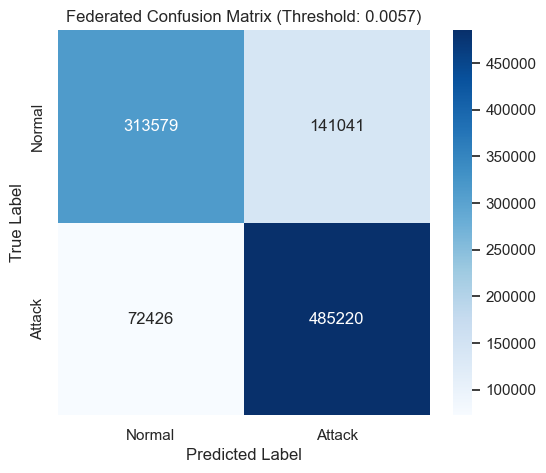

In [12]:
# 1. Confusion Matrix
cm = confusion_matrix(y_true_numeric, y_pred_optimal)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.title(f"Federated Confusion Matrix (Threshold: {optimal_threshold:.4f})")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()



/Users/sujannainawasti/miniconda3/envs/fl_project/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


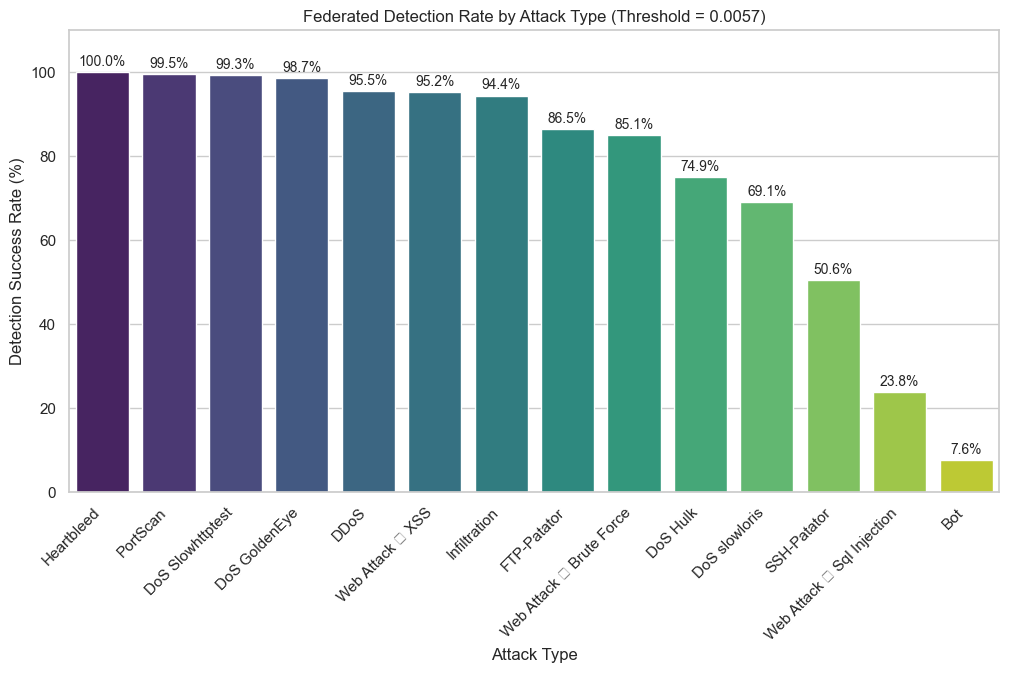

In [13]:
# 2. Attack Detection Breakdown
raw_labels = [str(label).strip() for label in y_test_global]
breakdown_df = pd.DataFrame({
    'Attack_Type': raw_labels,
    'Predicted_Status': ['Detected' if p == 1 else 'Missed' for p in y_pred_optimal]
})

attack_df = breakdown_df[breakdown_df['Attack_Type'] != 'BENIGN']
detection_stats = attack_df.groupby('Attack_Type')['Predicted_Status'].value_counts(normalize=True).unstack().fillna(0)

if "Detected" not in detection_stats.columns:
    detection_stats['Detected'] = 0.0

detection_rates = detection_stats['Detected'] * 100
detection_rates = detection_rates.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
# Setting hue to the index and legend=False fixes the Seaborn warning
sns.barplot(x=detection_rates.index, y=detection_rates.values, hue=detection_rates.index, palette='viridis', legend=False)
plt.title(f"Federated Detection Rate by Attack Type (Threshold = {optimal_threshold:.4f})")
plt.ylabel("Detection Success Rate (%)")
plt.xlabel("Attack Type")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 110)

for i, v in enumerate(detection_rates.values):
    plt.text(i, v + 1.5, f"{v:.1f}%", ha='center', fontsize=10)

plt.show()